In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("fertilizer_recommendation.csv")

print("Original shape:", df.shape)

Original shape: (10000, 20)


In [3]:
fertilizer_df = df[
    df["Crop_Type"].isin(["Rice", "Sugarcane"])
].copy()

print("Filtered shape:", fertilizer_df.shape)

print("\nCrop distribution:")
print(fertilizer_df["Crop_Type"].value_counts())

print("\nTarget distribution:")
print(fertilizer_df["Recommended_Fertilizer"].value_counts())

Filtered shape: (2857, 20)

Crop distribution:
Crop_Type
Rice         1429
Sugarcane    1428
Name: count, dtype: int64

Target distribution:
Recommended_Fertilizer
Urea             912
DAP              838
MOP              394
Compost          281
Zinc Sulphate    203
NPK              182
SSP               47
Name: count, dtype: int64


In [4]:
features = [
    "Crop_Type",
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_Level",
    "Phosphorus_Level",
    "Potassium_Level",
    "Electrical_Conductivity",
    "Crop_Growth_Stage"
]

target = "Recommended_Fertilizer"

X = fertilizer_df[features].copy()
y = fertilizer_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (2857, 8)
y shape: (2857,)


,Crop_Type,Soil_Type,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Electrical_Conductivity,Crop_Growth_Stage
5,Rice,Silt,4.85,48,31,87,1.23,Harvest
9,Rice,Loamy,6.22,158,51,39,1.44,Harvest
16,Rice,Silt,4.67,102,27,44,0.74,Sowing
17,Rice,Silt,5.79,88,74,75,0.52,Sowing
21,Rice,Sandy,6.24,21,27,90,2.00,Harvest


In [5]:
categorical_features = [
    "Crop_Type",
    "Soil_Type",
    "Crop_Growth_Stage"
]

numerical_features = [
    "Soil_pH",
    "Nitrogen_Level",
    "Phosphorus_Level",
    "Potassium_Level",
    "Electrical_Conductivity"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Crop_Type', 'Soil_Type', 'Crop_Growth_Stage']

Numerical features:
['Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Electrical_Conductivity']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 2285
Testing samples: 572

Training target distribution:
Recommended_Fertilizer
Urea             729
DAP              670
MOP              315
Compost          225
Zinc Sulphate    162
NPK              146
SSP               38
Name: count, dtype: int64

Testing target distribution:
Recommended_Fertilizer
Urea             183
DAP              168
MOP               79
Compost           56
Zinc Sulphate     41
NPK               36
SSP                9
Name: count, dtype: int64


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [8]:
def evaluate_model(name, model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Macro F1          : {macro_f1:.4f}")
    print(f"Weighted F1       : {weighted_f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_acc,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1
    }

In [9]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    "Random Forest",
    random_forest_pipeline,
    X_test,
    y_test
)

Random Forest
Accuracy          : 0.8986
Balanced Accuracy : 0.7680
Macro F1          : 0.7791
Weighted F1       : 0.8959

Classification Report:

               precision    recall  f1-score   support

      Compost       0.79      0.86      0.82        56
          DAP       0.93      0.96      0.94       168
          MOP       0.88      0.87      0.88        79
          NPK       0.84      0.72      0.78        36
          SSP       0.50      0.22      0.31         9
         Urea       0.97      0.96      0.96       183
Zinc Sulphate       0.74      0.78      0.76        41

     accuracy                           0.90       572
    macro avg       0.81      0.77      0.78       572
 weighted avg       0.90      0.90      0.90       572



In [10]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

gb_results = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_pipeline,
    X_test,
    y_test
)

Gradient Boosting
Accuracy          : 0.8986
Balanced Accuracy : 0.7716
Macro F1          : 0.7710
Weighted F1       : 0.8984

Classification Report:

               precision    recall  f1-score   support

      Compost       0.94      0.82      0.88        56
          DAP       0.95      0.95      0.95       168
          MOP       0.85      0.91      0.88        79
          NPK       0.66      0.81      0.72        36
          SSP       0.33      0.22      0.27         9
         Urea       0.98      0.96      0.97       183
Zinc Sulphate       0.73      0.73      0.73        41

     accuracy                           0.90       572
    macro avg       0.78      0.77      0.77       572
 weighted avg       0.90      0.90      0.90       572



In [14]:
# ============================================================
# DECISION TREE MODEL
# ============================================================

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
                max_depth=8
            )
        )
    ]
)

# Train model
decision_tree_pipeline.fit(X_train, y_train)

# Evaluate model and STORE the result
dt_results = evaluate_model(
    "Decision Tree",
    decision_tree_pipeline,
    X_test,
    y_test
)

print("\nDecision Tree result variable created:")
print(dt_results)

Decision Tree
Accuracy          : 0.8951
Balanced Accuracy : 0.8004
Macro F1          : 0.7767
Weighted F1       : 0.9167

Classification Report:

               precision    recall  f1-score   support

      Compost       1.00      0.79      0.88        56
          DAP       0.99      0.95      0.97       168
          MOP       1.00      0.87      0.93        79
          NPK       0.53      0.89      0.67        36
          SSP       0.11      0.44      0.18         9
         Urea       1.00      0.95      0.97       183
Zinc Sulphate       1.00      0.71      0.83        41

     accuracy                           0.90       572
    macro avg       0.81      0.80      0.78       572
 weighted avg       0.95      0.90      0.92       572


Decision Tree result variable created:
{'Model': 'Decision Tree', 'Accuracy': 0.8951048951048951, 'Balanced_Accuracy': 0.8004261483213482, 'Macro_F1': 0.7767032860506845, 'Weighted_F1': 0.9166796578862798}


In [15]:
model_results = pd.DataFrame(
    [
        dt_results,
        rf_results,
        gb_results
    ]
)

model_results = model_results.sort_values(
    "Macro_F1",
    ascending=False
)

display(
    model_results.round(4)
)

,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
1,Random Forest,0.8986,0.7680,0.7791,0.8959
0,Decision Tree,0.8951,0.8004,0.7767,0.9167
2,Gradient Boosting,0.8986,0.7716,0.7710,0.8984


In [16]:
print("dt_results exists:", "dt_results" in globals())
print("rf_results exists:", "rf_results" in globals())
print("gb_results exists:", "gb_results" in globals())

dt_results exists: True
rf_results exists: True
gb_results exists: True


In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

dt_pipeline_tuning = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

param_grid = {
    "classifier__max_depth": [5, 6, 7, 8, 9, 10, 12, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=dt_pipeline_tuning,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters:
{'classifier__max_depth': 6, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}

Best CV Macro F1:
0.8003


In [18]:
best_dt_model = grid_search.best_estimator_

best_dt_results = evaluate_model(
    "Tuned Decision Tree",
    best_dt_model,
    X_test,
    y_test
)

Tuned Decision Tree
Accuracy          : 0.8934
Balanced Accuracy : 0.8560
Macro F1          : 0.8070
Weighted F1       : 0.9283

Classification Report:

               precision    recall  f1-score   support

      Compost       1.00      0.79      0.88        56
          DAP       1.00      0.95      0.98       168
          MOP       1.00      0.87      0.93        79
          NPK       1.00      0.72      0.84        36
          SSP       0.13      1.00      0.23         9
         Urea       1.00      0.95      0.97       183
Zinc Sulphate       0.97      0.71      0.82        41

     accuracy                           0.89       572
    macro avg       0.87      0.86      0.81       572
 weighted avg       0.98      0.89      0.93       572



In [19]:
dt_comparison = pd.DataFrame(
    [
        dt_results,
        best_dt_results
    ]
)

display(
    dt_comparison.round(4)
)

,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,Decision Tree,0.8951,0.8004,0.7767,0.9167
1,Tuned Decision Tree,0.8934,0.8560,0.8070,0.9283


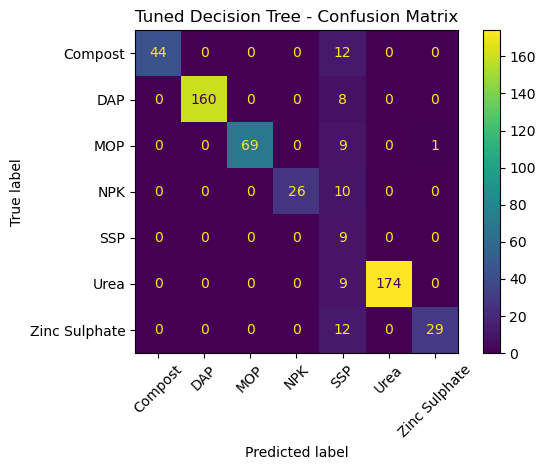

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_predictions = best_dt_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    xticks_rotation=45
)

plt.title("Tuned Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# FINAL DECISION TREE TUNING
# Compare normal vs balanced class weighting
# ============================================================

final_param_grid = {
    "classifier__max_depth": [5, 6, 7, 8, 9, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

final_dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

final_grid_search = GridSearchCV(
    estimator=final_dt_pipeline,
    param_grid=final_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

final_grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(final_grid_search.best_params_)

print("\nBest CV Macro F1:")
print(round(final_grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}

Best CV Macro F1:
0.8003


In [22]:
final_dt_model = final_grid_search.best_estimator_

final_dt_results = evaluate_model(
    "Final Tuned Decision Tree",
    final_dt_model,
    X_test,
    y_test
)

Final Tuned Decision Tree
Accuracy          : 0.8934
Balanced Accuracy : 0.8560
Macro F1          : 0.8070
Weighted F1       : 0.9283

Classification Report:

               precision    recall  f1-score   support

      Compost       1.00      0.79      0.88        56
          DAP       1.00      0.95      0.98       168
          MOP       1.00      0.87      0.93        79
          NPK       1.00      0.72      0.84        36
          SSP       0.13      1.00      0.23         9
         Urea       1.00      0.95      0.97       183
Zinc Sulphate       0.97      0.71      0.82        41

     accuracy                           0.89       572
    macro avg       0.87      0.86      0.81       572
 weighted avg       0.98      0.89      0.93       572



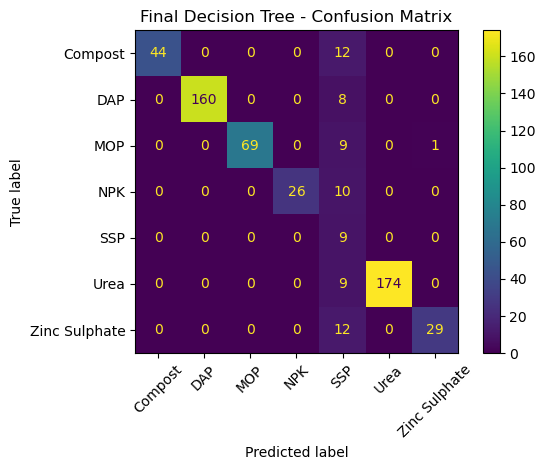

In [23]:
final_predictions = final_dt_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    xticks_rotation=45
)

plt.title("Final Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
final_comparison = pd.DataFrame(
    [
        dt_results,
        rf_results,
        gb_results,
        final_dt_results
    ]
)

final_comparison = final_comparison.sort_values(
    "Macro_F1",
    ascending=False
)

display(final_comparison.round(4))

,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
3,Final Tuned Decision Tree,0.8934,0.8560,0.8070,0.9283
1,Random Forest,0.8986,0.7680,0.7791,0.8959
0,Decision Tree,0.8951,0.8004,0.7767,0.9167
2,Gradient Boosting,0.8986,0.7716,0.7710,0.8984


In [25]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/fertilizer_recommendation_model.pkl"

joblib.dump(
    final_dt_model,
    model_path
)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
../models/fertilizer_recommendation_model.pkl


In [26]:
loaded_model = joblib.load(
    "../models/fertilizer_recommendation_model.pkl"
)

print("Model loaded successfully.")
print(type(loaded_model))

Model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [27]:
test_sample = pd.DataFrame(
    [{
        "Crop_Type": "Rice",
        "Soil_Type": "Loamy",
        "Soil_pH": 6.5,
        "Nitrogen_Level": 45,
        "Phosphorus_Level": 55,
        "Potassium_Level": 70,
        "Electrical_Conductivity": 1.2,
        "Crop_Growth_Stage": "Vegetative"
    }]
)

prediction = loaded_model.predict(test_sample)[0]

print("Recommended Fertilizer:", prediction)

Recommended Fertilizer: Urea


In [28]:
test_sample_sugarcane = pd.DataFrame(
    [{
        "Crop_Type": "Sugarcane",
        "Soil_Type": "Clay",
        "Soil_pH": 6.8,
        "Nitrogen_Level": 110,
        "Phosphorus_Level": 25,
        "Potassium_Level": 75,
        "Electrical_Conductivity": 1.5,
        "Crop_Growth_Stage": "Vegetative"
    }]
)

prediction = loaded_model.predict(
    test_sample_sugarcane
)[0]

print("Recommended Fertilizer:", prediction)

Recommended Fertilizer: DAP


In [29]:
probabilities = loaded_model.predict_proba(
    test_sample
)[0]

classes = loaded_model.classes_

probability_table = pd.DataFrame({
    "Fertilizer": classes,
    "Probability": probabilities
}).sort_values(
    "Probability",
    ascending=False
)

display(probability_table)

,Fertilizer,Probability
5,Urea,1.0
0,Compost,0.0
1,DAP,0.0
2,MOP,0.0
3,NPK,0.0
4,SSP,0.0
6,Zinc Sulphate,0.0


## Final Model Selection

The Tuned Decision Tree was selected as the prototype fertilizer
classification model.

Performance:

- Accuracy: 0.8934
- Balanced Accuracy: 0.8560
- Macro F1: 0.8070
- Weighted F1: 0.9283

Best parameters:

- class_weight = balanced
- max_depth = 6
- min_samples_leaf = 2
- min_samples_split = 2

Important limitation:

The SSP class has very low precision despite high recall because only a
small number of SSP observations are available. SSP predictions therefore
require additional validation.

The underlying dataset appears to contain structured/synthetic fertilizer
recommendation rules. Therefore, this model is intended for prototype
decision-support and must not be represented as a field-validated
fertilizer prescription model.

Crop: Sugarcane
Recommended fertilizer: DAP
Model probability: 92%

Reason:
The measured phosphorus level is low relative to the
patterns represented in the recommendation dataset.

Nutrient status:
Nitrogen   → Adequate
Phosphorus → Low
Potassium  → Adequate

Prototype warning:
Recommendation requires agronomic validation before field application.